## Task 2: Identifying Engagement Groups in Facebook Live Selling Using Clustering Techniques

## Libraries

In [1]:
#Impor t Required Libraries 
# Data handling and manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# Evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

# (Optional) Fix for threading issues on some systems (Windows/Colab)

import os
os.environ["OMP_NUM_THREADS"] = '1'


In [2]:
# ---- Load the dataset ----
# Import the dataset "Live_20210128.csv" into a pandas DataFrame.
# This dataset contains engagement metrics (likes, comments, shares, etc.)
# from Facebook Live sellers in Thailand.

df = pd.read_csv("Live_20210128.csv")

# Print the shape of the dataset (rows, columns) to understand its size.
print(df.shape)

(7050, 16)


## Exploratory Data Analysis

In [3]:
# Display the first 5 rows to preview the dataset and check the structure.
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [4]:
# Display the bottom 5 rows.
df.tail()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
7045,7046,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0,NaN,NaN,NaN,NaN
7046,7047,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0,NaN,NaN,NaN,NaN
7047,7048,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN
7048,7049,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0,NaN,NaN,NaN,NaN
7049,7050,photo,9/10/2016 10:30,17,0,0,17,0,0,0,0,0,NaN,NaN,NaN,NaN


In [5]:
# View basic structure of the dataset
# Shows the number of rows, columns, data types, and memory usage.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   str    
 2   status_published  7050 non-null   str    
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), str(2)
memory usage: 881.4 

In [6]:
# View descriptive statistics for numeric columns
# Provides summary statistics: count, mean, std, min, quartiles, max.
# Useful for detecting skewness, outliers, and scale differences across features.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
status_id,7050.0,3525.500000,2035.304031,1.0,1763.25,3525.5,5287.75,7050.0
num_reactions,7050.0,230.117163,462.625309,0.0,17.00,59.5,219.00,4710.0
num_comments,7050.0,224.356028,889.636820,0.0,0.00,4.0,23.00,20990.0
num_shares,7050.0,40.022553,131.599965,0.0,0.00,0.0,4.00,3424.0
num_likes,7050.0,215.043121,449.472357,0.0,17.00,58.0,184.75,4710.0
num_loves,7050.0,12.728652,39.972930,0.0,0.00,0.0,3.00,657.0
num_wows,7050.0,1.289362,8.719650,0.0,0.00,0.0,0.00,278.0
num_hahas,7050.0,0.696454,3.957183,0.0,0.00,0.0,0.00,157.0
num_sads,7050.0,0.243688,1.597156,0.0,0.00,0.0,0.00,51.0
num_angrys,7050.0,0.113191,0.726812,0.0,0.00,0.0,0.00,31.0


In [7]:
# Check for missing values in each column
# Ensures there are no missing values that might affect clustering.
df.isnull().sum()

status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64

In [8]:
# Drop empty and unnecessary columns
df_clean = df.drop(columns=["Column1","Column2","Column3","Column4"])
# Display the first 5 rows to preview the dataset
df_clean.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0


In [9]:
# Check for missing values again in each column
print(df_clean.isnull().sum())

status_id           0
status_type         0
status_published    0
num_reactions       0
num_comments        0
num_shares          0
num_likes           0
num_loves           0
num_wows            0
num_hahas           0
num_sads            0
num_angrys          0
dtype: int64


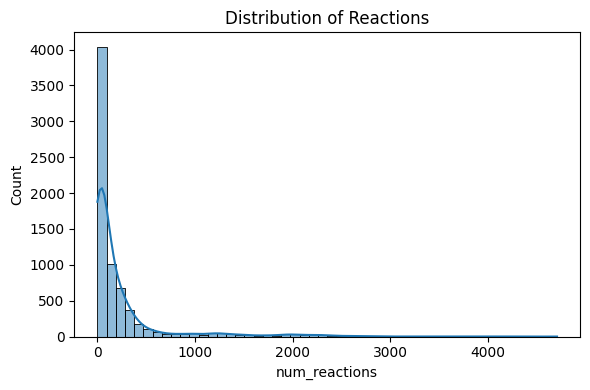

In [10]:
# EDA: key plots for the report
#  Histogram: Reactions
plt.figure(figsize=(6,4))
sns.histplot(df_clean["num_reactions"], bins=50, kde=True)
plt.title("Distribution of Reactions")
plt.xlabel("num_reactions"); plt.ylabel("Count")
plt.tight_layout(); 
plt.show()

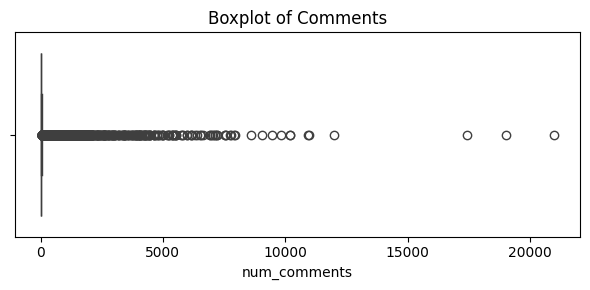

In [11]:
# Boxplot: Comments (shows outliers / viral posts)
plt.figure(figsize=(6,3))
sns.boxplot(x=df_clean["num_comments"])
plt.title("Boxplot of Comments")
plt.xlabel("num_comments")
plt.tight_layout();
plt.show()

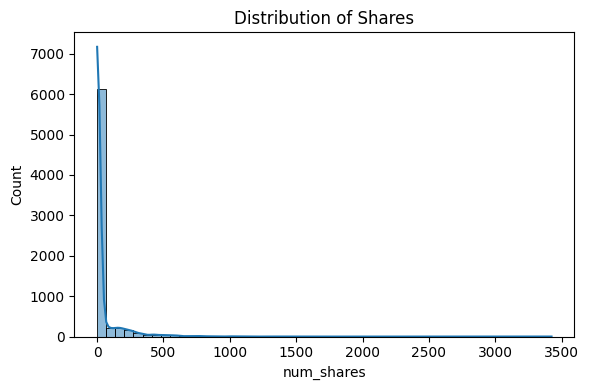

In [12]:
# Histogram: Shares
plt.figure(figsize=(6,4))
sns.histplot(df_clean["num_shares"], bins=50, kde=True)
plt.title("Distribution of Shares")
plt.xlabel("num_shares"); plt.ylabel("Count")
plt.tight_layout(); 
plt.show()

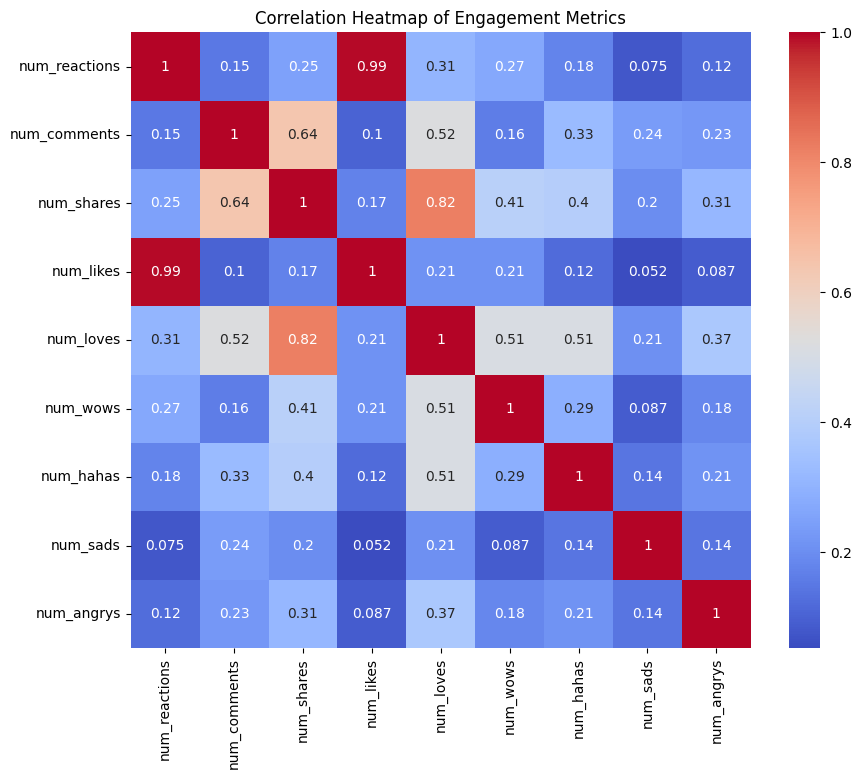

In [13]:
# Plot heatmap to visualize correlations among engagement metrics
# Focuses only on columns 3 to 12 (numeric engagement features)
# 'annot=True' shows the correlation values in each cell
# 'cmap="coolwarm"' gives a diverging color scheme (blue = negative, red = positive)

plt.figure(figsize=(10,8))
sns.heatmap(df_clean.iloc[:,3:12].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Engagement Metrics")
plt.show()


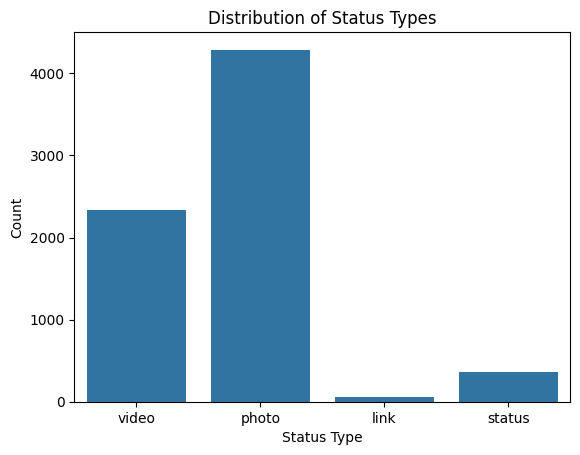

Percentage distribution of each status type:
status_type
photo     60.822695
video     33.106383
status     5.177305
link       0.893617
Name: proportion, dtype: float64


In [14]:
# Distribution of Status Types 

# Using countplot categorical variables like 'status_type'
# It shows how many posts fall into each category (e.g., photo, video, status, link)
sns.countplot(x=df['status_type'])  

# Add a title
plt.title('Distribution of Status Types')

# Label the x-axis (categories of status type)
plt.xlabel('Status Type')
# Label the y-axis (number of posts in each category)
plt.ylabel('Count')
# Display the plot
plt.show()

# Print percentage distribution of each status type
# 'normalize=True' ensures values are shown as proportions, multiplied by 100 to get percentages
print("Percentage distribution of each status type:")
print(df_clean["status_type"].value_counts(normalize=True) * 100)

### Plot of Key Engagement Features

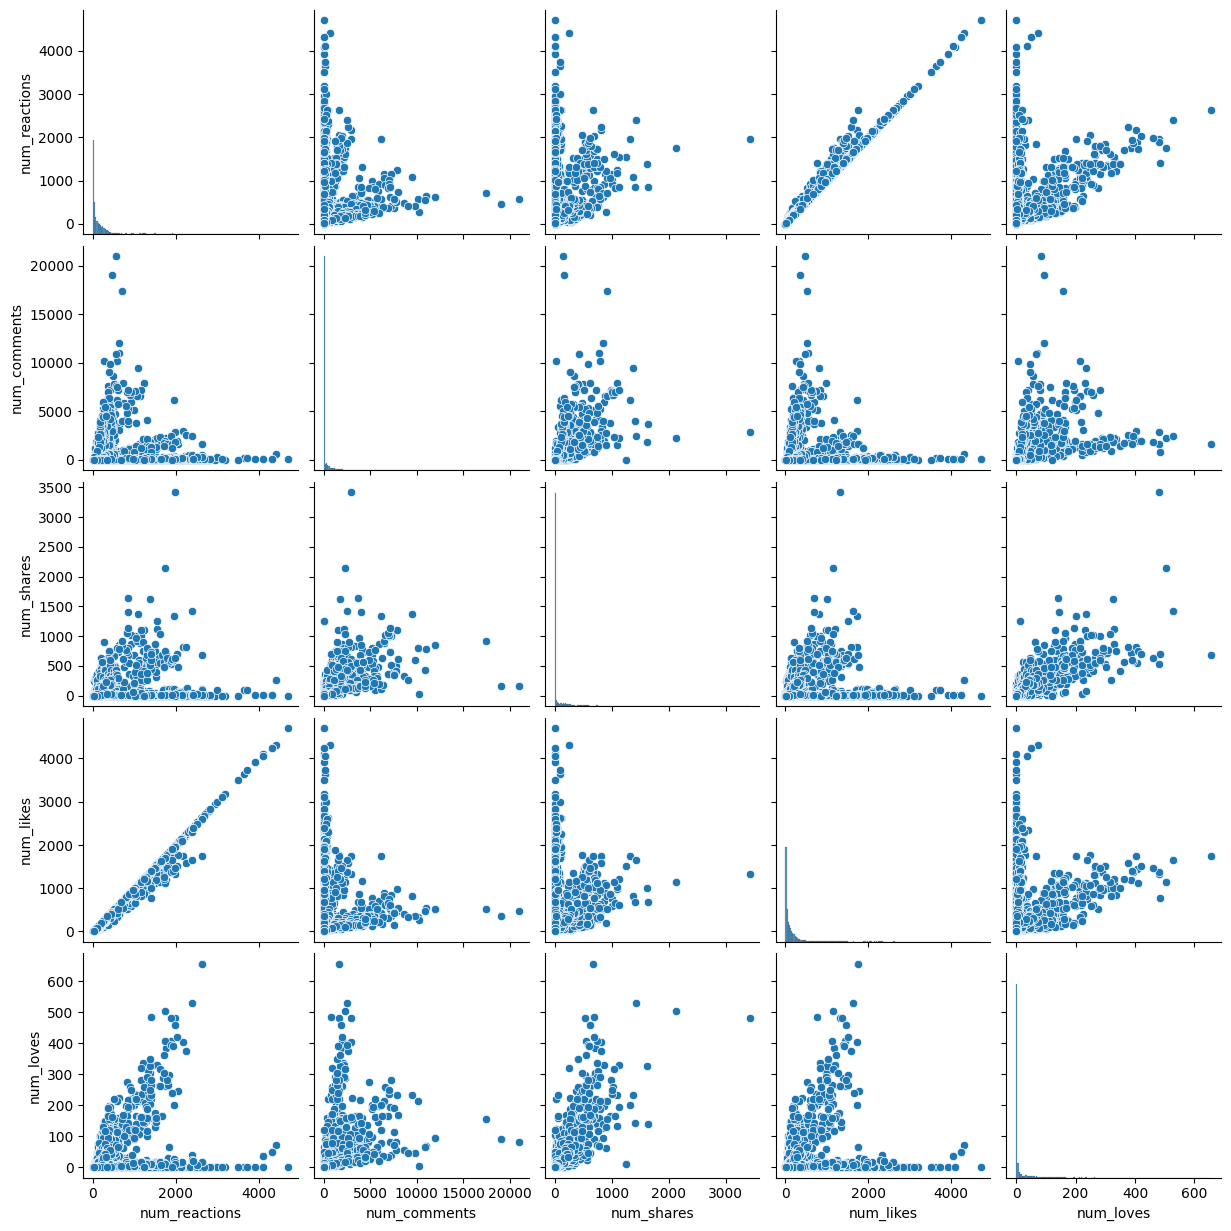

In [15]:
# Pairplot of Key Engagement Features
# Create pairwise scatterplots to explore relationships between variables
# Selecting only a subset of numeric features for clarity:
#   - num_reactions, num_comments, num_shares, num_likes, num_loves

sns.pairplot(df_clean.iloc[:, [3, 4, 5, 6, 7]])  

# Display the plots
plt.show()

### Data Preprocessing

In [16]:
# Select the feature columns (columns 3 to 11) for clustering
# These are the numeric engagement metrics: reactions, comments, shares, likes, loves, wows, hahas, sads, angrys
X = df_clean.iloc[:, 3:12].values   

# Initialize the StandardScaler to normalize/standardize the data
# Standardization ensures each feature has mean = 0 and standard deviation = 1
sc_X = StandardScaler()

# Fit the scaler to the data and transform it
# This step applies the scaling so that features are on the same scale, improving clustering performance
X = sc_X.fit_transform(X)

# Display the scaled feature matrix (optional)
X


array([[ 0.64610394,  0.32335035,  1.6868788 , ...,  0.07671305,
         0.47357035, -0.15574803],
       [-0.17319166, -0.25220622, -0.3041444 , ..., -0.17600986,
        -0.152587  , -0.15574803],
       [-0.00673846,  0.01308938,  0.12901714, ...,  0.07671305,
        -0.152587  , -0.15574803],
       ...,
       [-0.49312768, -0.25220622, -0.3041444 , ..., -0.17600986,
        -0.152587  , -0.15574803],
       [ 0.26131603, -0.23871662, -0.13695924, ..., -0.17600986,
        -0.152587  , -0.15574803],
       [-0.46070173, -0.25220622, -0.3041444 , ..., -0.17600986,
        -0.152587  , -0.15574803]], shape=(7050, 9))

### Elbow method for K

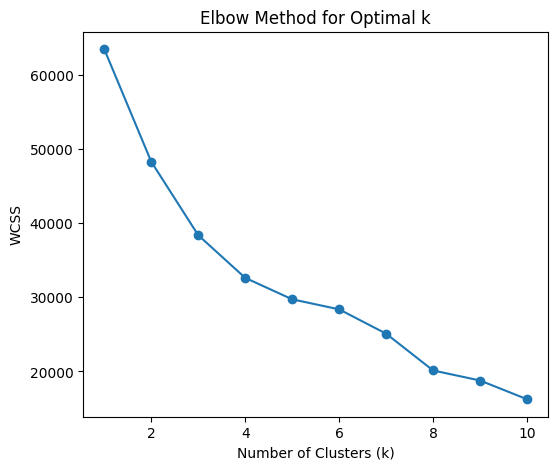

In [17]:
wcss = []

# Try k = 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)   # X = standardized engagement features
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(6,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()


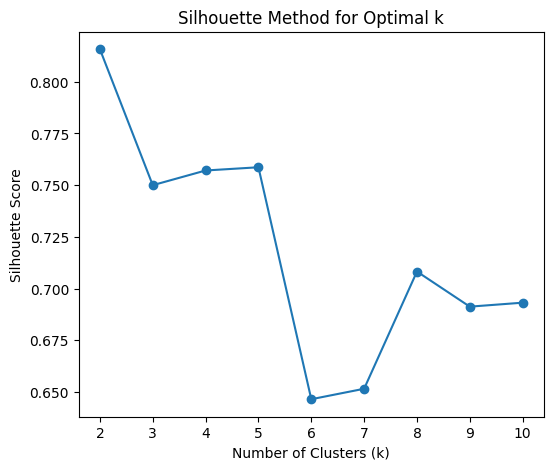

In [18]:
silhouette_scores = []

# Try k = 2 to 10 (silhouette not defined for k=1)
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

# Plot
plt.figure(figsize=(6,5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()


###  K-Means clustering 

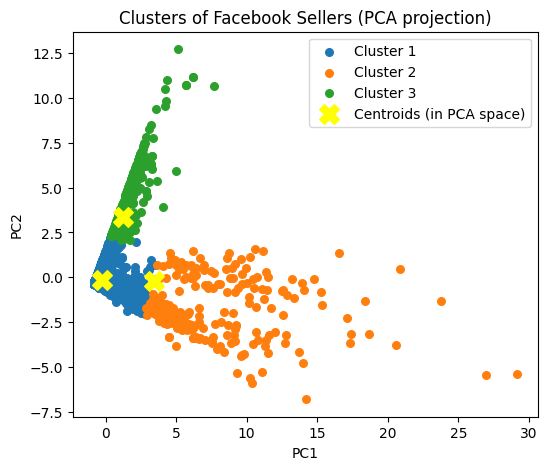

In [19]:
# ---- K-Means clustering with k=3 ----

# Initialize K-Means with 3 clusters using k-means++ for better centroid initialization
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
labels = kmeans.fit_predict(X)   # Fit model and assign each point to a cluster

# ---- Dimensionality reduction with PCA (2D for plotting) ----
pca = PCA(n_components=2)        # Reduce to 2 principal components
X_pca = pca.fit_transform(X)     # Transform scaled data into 2D space

# ---- Scatter plot of clusters ----
plt.figure(figsize=(6,5))
for cluster in range(kmeans.n_clusters):
    # Plot each cluster's points in different colors
    plt.scatter(X_pca[labels==cluster, 0], X_pca[labels==cluster, 1], 
                s=30, label=f"Cluster {cluster+1}")

# Plot cluster centroids (projected into PCA space)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            s=200, c="yellow", marker="X", label="Centroids (in PCA space)")

# Axis labels and title
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Clusters of Facebook Sellers (PCA projection)")
plt.legend()
plt.show()

###  hierarchical dendrogram

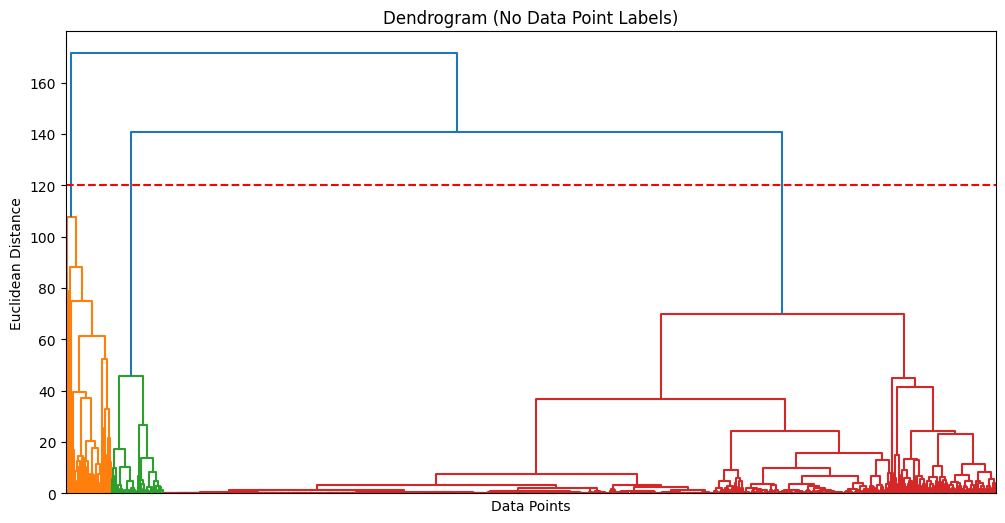

In [20]:
# ---- Plot a hierarchical dendrogram using Ward linkage ----
plt.figure(figsize=(12, 6))  

# Create the dendrogram
# 'ward' method merges clusters by minimising variance
# no_labels=True hides the individual sample labels, which makes the plot
# much cleaner when you have thousands of data points
dendrogram = sch.dendrogram(
    sch.linkage(X, method='ward'),
    no_labels=True
)

# Add titles and axis labels
plt.title("Dendrogram (No Data Point Labels)")
plt.xlabel("Data Points")                # Each leaf = one observation
plt.ylabel("Euclidean Distance")         # Y-axis shows distance between merged clusters

# Draw a horizontal red line at y=35000 to show the chosen cut-off
# Cutting here yields 3 main clusters
plt.axhline(y=120, color='r', linestyle='--')

# Display the plot
plt.show()

### Agglomerative clustering

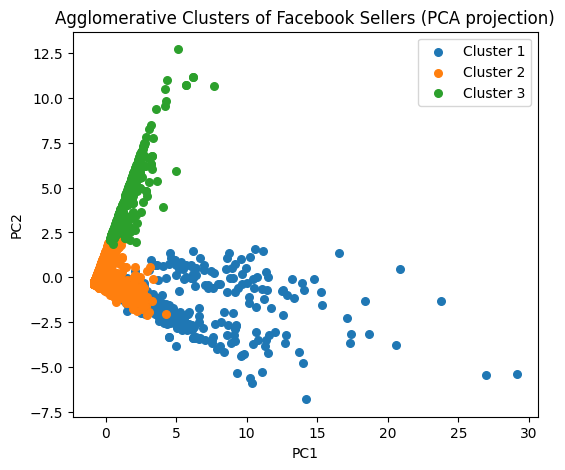

In [21]:
# ---- Agglomerative clustering with 3 clusters ----
# Ward linkage is used to minimize variance within clusters
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg_labels = agg.fit_predict(X)   # Fit model and assign cluster labels

# ---- PCA projection (2D for visualization) ----
# Reuse the PCA-reduced data (X_pca) created earlier
plt.figure(figsize=(6,5))
for cluster in np.unique(agg_labels):
    # Plot each cluster in a different color
    plt.scatter(X_pca[agg_labels==cluster, 0], X_pca[agg_labels==cluster, 1],
                s=30, label=f"Cluster {cluster+1}")

# Add labels and title
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Agglomerative Clusters of Facebook Sellers (PCA projection)")
plt.legend()
plt.show()


### Evaluation of Metrics

In [22]:
# -- Evaluation Metrics
# Silhouette Score -> measures cluster cohesion vs separation (-1 to 1, higher is better)
# Davies-Bouldin Index (DBI) -> measures compactness vs separation (lower is better)

# ---- Evaluate K-Means clustering ----
# 'labels' = cluster assignments from K-Means
sil_kmeans = silhouette_score(X, labels)        # Compute average silhouette score
dbi_kmeans = davies_bouldin_score(X, labels)    # Compute Davies-Bouldin Index

# ---- Evaluate Agglomerative clustering ----
# 'agg_labels' = cluster assignments from Agglomerative=
sil_agg = silhouette_score(X, agg_labels)       # Silhouette score

dbi_agg = davies_bouldin_score(X, agg_labels)   # Davies-Bouldin Index

# ---- Print results for comparison ----
print("K-Means -> Silhouette:", sil_kmeans, "DBI:", dbi_kmeans)
print("Agglomerative -> Silhouette:", sil_agg, "DBI:", dbi_agg)


K-Means -> Silhouette: 0.7499921477392748 DBI: 1.1033698217676753
Agglomerative -> Silhouette: 0.7485709193412028 DBI: 1.1497610402627128


In [23]:
# ---- Create a copy of the cleaned dataset ----
df_clusters = df_clean.copy()

# ---- Add K-Means cluster assignments ----
# By default, labels are 0, 1, 2
# Adding +1 makes them 1, 2, 3 (easier for reporting)
df_clusters["Cluster"] = labels + 1


### Display the cluster profile

In [24]:
# ---- Define engagement features ----
engagement_cols = ["num_reactions","num_comments","num_shares",
                   "num_likes","num_loves","num_wows",
                   "num_hahas","num_sads","num_angrys"]

# ---- Group by cluster and calculate mean values ----
cluster_profile = df_clusters.groupby("Cluster")[engagement_cols].mean().round(2)

# ---- Display the cluster profile ----
print(cluster_profile)


         num_reactions  num_comments  num_shares  num_likes  num_loves  \
Cluster                                                                  
1               113.85        106.23       21.71     105.29       7.46   
2               786.87       3217.95      508.30     606.29     149.34   
3              1823.31         61.33       11.65    1817.53       3.10   

         num_wows  num_hahas  num_sads  num_angrys  
Cluster                                             
1            0.55       0.34      0.15        0.05  
2           17.08       9.75      2.76        1.65  
3            2.44       0.20      0.03        0.01  


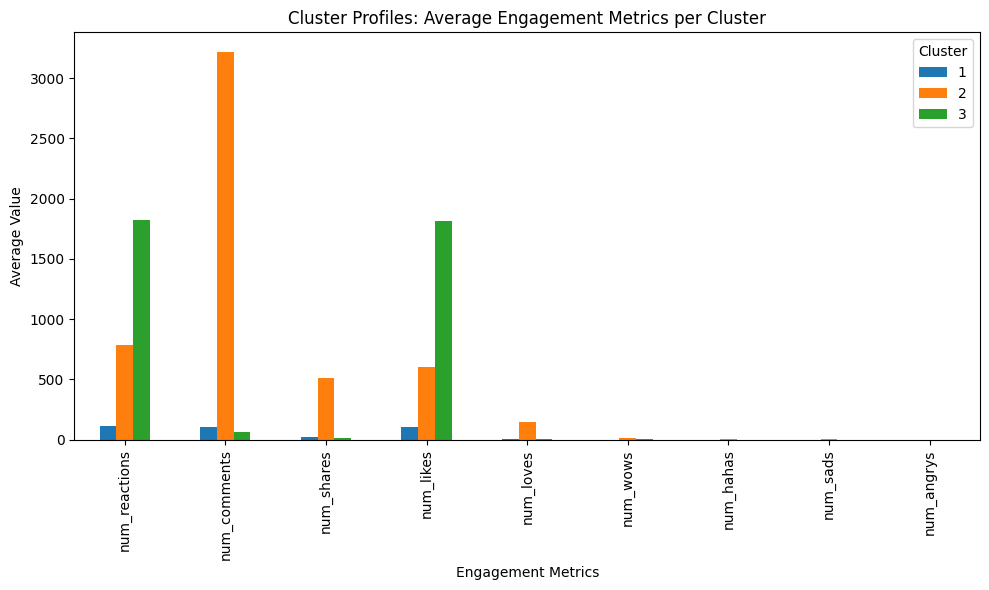

In [25]:
# ---- Plot cluster profiles as a bar chart ----
ax = cluster_profile.T.plot(kind="bar", figsize=(10,6))

# Add labels and title
plt.title("Cluster Profiles: Average Engagement Metrics per Cluster")
plt.xlabel("Engagement Metrics")
plt.ylabel("Average Value")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [26]:
# Count how many posts belong to each cluster
cluster_sizes = df_clusters["Cluster"].value_counts().sort_index()

# Rename the index to show Cluster 1, Cluster 2, Cluster 3 instead of numbers
cluster_sizes.index = [f"Cluster {i}" for i in cluster_sizes.index]

# Print with readable labels
print(cluster_sizes)



Cluster 1    6405
Cluster 2     273
Cluster 3     372
Name: count, dtype: int64


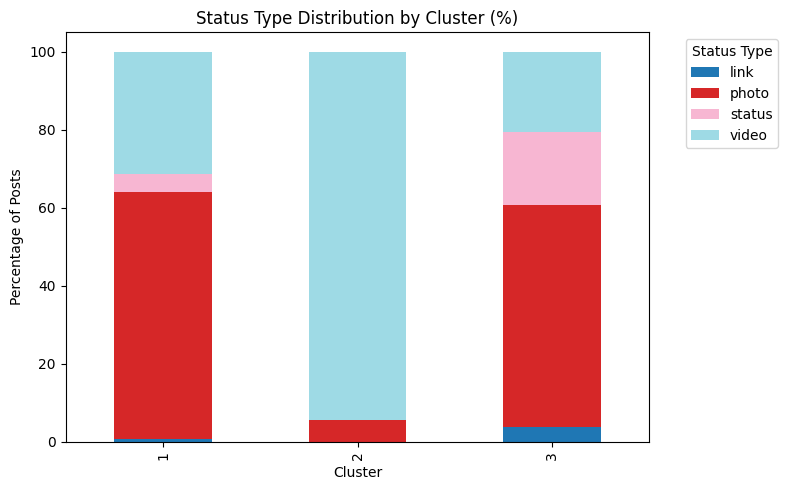

In [27]:
# Cross-tabulate clusters and status_type
ct = pd.crosstab(df_clusters["Cluster"], df_clean["status_type"], normalize="index") * 100

# Plot as stacked bar chart
ct.plot(kind="bar", stacked=True, figsize=(8,5), colormap="tab20")

plt.title("Status Type Distribution by Cluster (%)")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Posts")
plt.legend(title="Status Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
